In [5]:
import pickle
import os
import pandas as pd
import networkx as nx
import numpy as np
import random
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
import scipy.stats as scp
from scipy.stats import ranksums, wilcoxon
import tidepy
import gzip
import chardet

In [2]:
hippiedata="/home/ajayasha/scratch/Arvind_umd/ECM_proj/hippie/"
congenelistdata="/home/ajayasha/scratch/Arvind_umd/ECM_proj/genelist/contextecmcm/"
genelistdata="/home/ajayasha/scratch/Arvind_umd/ECM_proj/genelist/"
UCSCtoilpath="/home/ajayasha/scratch/Arvind_umd/UCSC-TOIL/"
ECMprojpath="/home/ajayasha/scratch/Arvind_umd/ECM_proj/"
RCDprojpath="/home/ajayasha/scratch/Arvind_umd/RCD/"
GDCPANCANpath="/home/ajayasha/scratch/Arvind_umd/GDC-PANCAN/"
depmappath="/home/ajayasha/scratch/Arvind_umd/depmap/"
datapath="/home/ajayasha/scratch/Arvind_umd/"

In [6]:
rawdata = gzip.open(UCSCtoilpath+"TcgaTargetGTEX_phenotype.txt.gz", "rb").read()
result = chardet.detect(rawdata)
charenc = result['encoding']
cat_sample=pd.read_csv(UCSCtoilpath+"TcgaTargetGTEX_phenotype.txt.gz", sep="\t",index_col=0,encoding=charenc)

In [7]:
cat_sample.dropna(inplace=True,how='all')

In [12]:
cat_sample.drop(cat_sample[cat_sample["_study"]=="GTEX"].index,inplace=True)

In [14]:
cat_sample['_sample_type'].unique()

array(['Primary Tumor', 'Solid Tissue Normal', 'Recurrent Tumor',
       'Metastatic', 'Additional - New Primary', 'Additional Metastatic',
       'Primary Blood Derived Cancer - Peripheral Blood',
       'Control Analyte', 'Recurrent Solid Tumor', 'Primary Solid Tumor',
       'Recurrent Blood Derived Cancer - Bone Marrow',
       'Primary Blood Derived Cancer - Bone Marrow',
       'Post treatment Blood Cancer - Bone Marrow',
       'Post treatment Blood Cancer - Blood',
       'Recurrent Blood Derived Cancer - Peripheral Blood'], dtype=object)

In [15]:
cat_sample.drop(cat_sample[cat_sample["_sample_type"]=="Solid Tissue Normal"].index,inplace=True)
cat_sample.drop(cat_sample[cat_sample["_sample_type"]=="Control Analyte"].index,inplace=True)

In [16]:
cat_sdict=dict(cat_sample['primary disease or tissue']+"_"+cat_sample['_primary_site']+"_"+cat_sample['_sample_type'])

In [17]:
cat_sdict

{'TCGA-V4-A9EE-01': 'Uveal Melanoma_Eye_Primary Tumor',
 'TCGA-VD-AA8N-01': 'Uveal Melanoma_Eye_Primary Tumor',
 'TCGA-V4-A9EI-01': 'Uveal Melanoma_Eye_Primary Tumor',
 'TCGA-VD-AA8O-01': 'Uveal Melanoma_Eye_Primary Tumor',
 'TCGA-WC-A888-01': 'Uveal Melanoma_Eye_Primary Tumor',
 'TCGA-WC-A881-01': 'Uveal Melanoma_Eye_Primary Tumor',
 'TCGA-WC-A88A-01': 'Uveal Melanoma_Eye_Primary Tumor',
 'TCGA-YZ-A980-01': 'Uveal Melanoma_Eye_Primary Tumor',
 'TCGA-V4-A9EO-01': 'Uveal Melanoma_Eye_Primary Tumor',
 'TCGA-WC-A87U-01': 'Uveal Melanoma_Eye_Primary Tumor',
 'TCGA-VD-A8KD-01': 'Uveal Melanoma_Eye_Primary Tumor',
 'TCGA-VD-AA8Q-01': 'Uveal Melanoma_Eye_Primary Tumor',
 'TCGA-VD-A8KH-01': 'Uveal Melanoma_Eye_Primary Tumor',
 'TCGA-V4-A9F8-01': 'Uveal Melanoma_Eye_Primary Tumor',
 'TCGA-VD-A8KF-01': 'Uveal Melanoma_Eye_Primary Tumor',
 'TCGA-VD-A8KI-01': 'Uveal Melanoma_Eye_Primary Tumor',
 'TCGA-V4-A9EA-01': 'Uveal Melanoma_Eye_Primary Tumor',
 'TCGA-VD-A8KM-01': 'Uveal Melanoma_Eye_Primary 

In [18]:
tcgagenemap=pd.read_csv(UCSCtoilpath+"probeMap%2Fgencode.v23.annotation.gene.probemap",sep="\t",index_col=0)

In [19]:
enslist=tcgagenemap.index.to_series().apply(lambda x: x.split('.')[0]).values.tolist()
print(len(enslist))#ensids
print(len(list(set(enslist))))#unique ensids

60498
60498


In [20]:
can_dict={}
can_dict_counts={}
for s in cat_sdict:
    if cat_sdict[s] not in can_dict.keys():
        can_dict[cat_sdict[s]]=[]
        can_dict[cat_sdict[s]].append(s)
    else:
        can_dict[cat_sdict[s]].append(s)
for c in can_dict:
    can_dict_counts[c]=len(can_dict[c])

<Axes: >

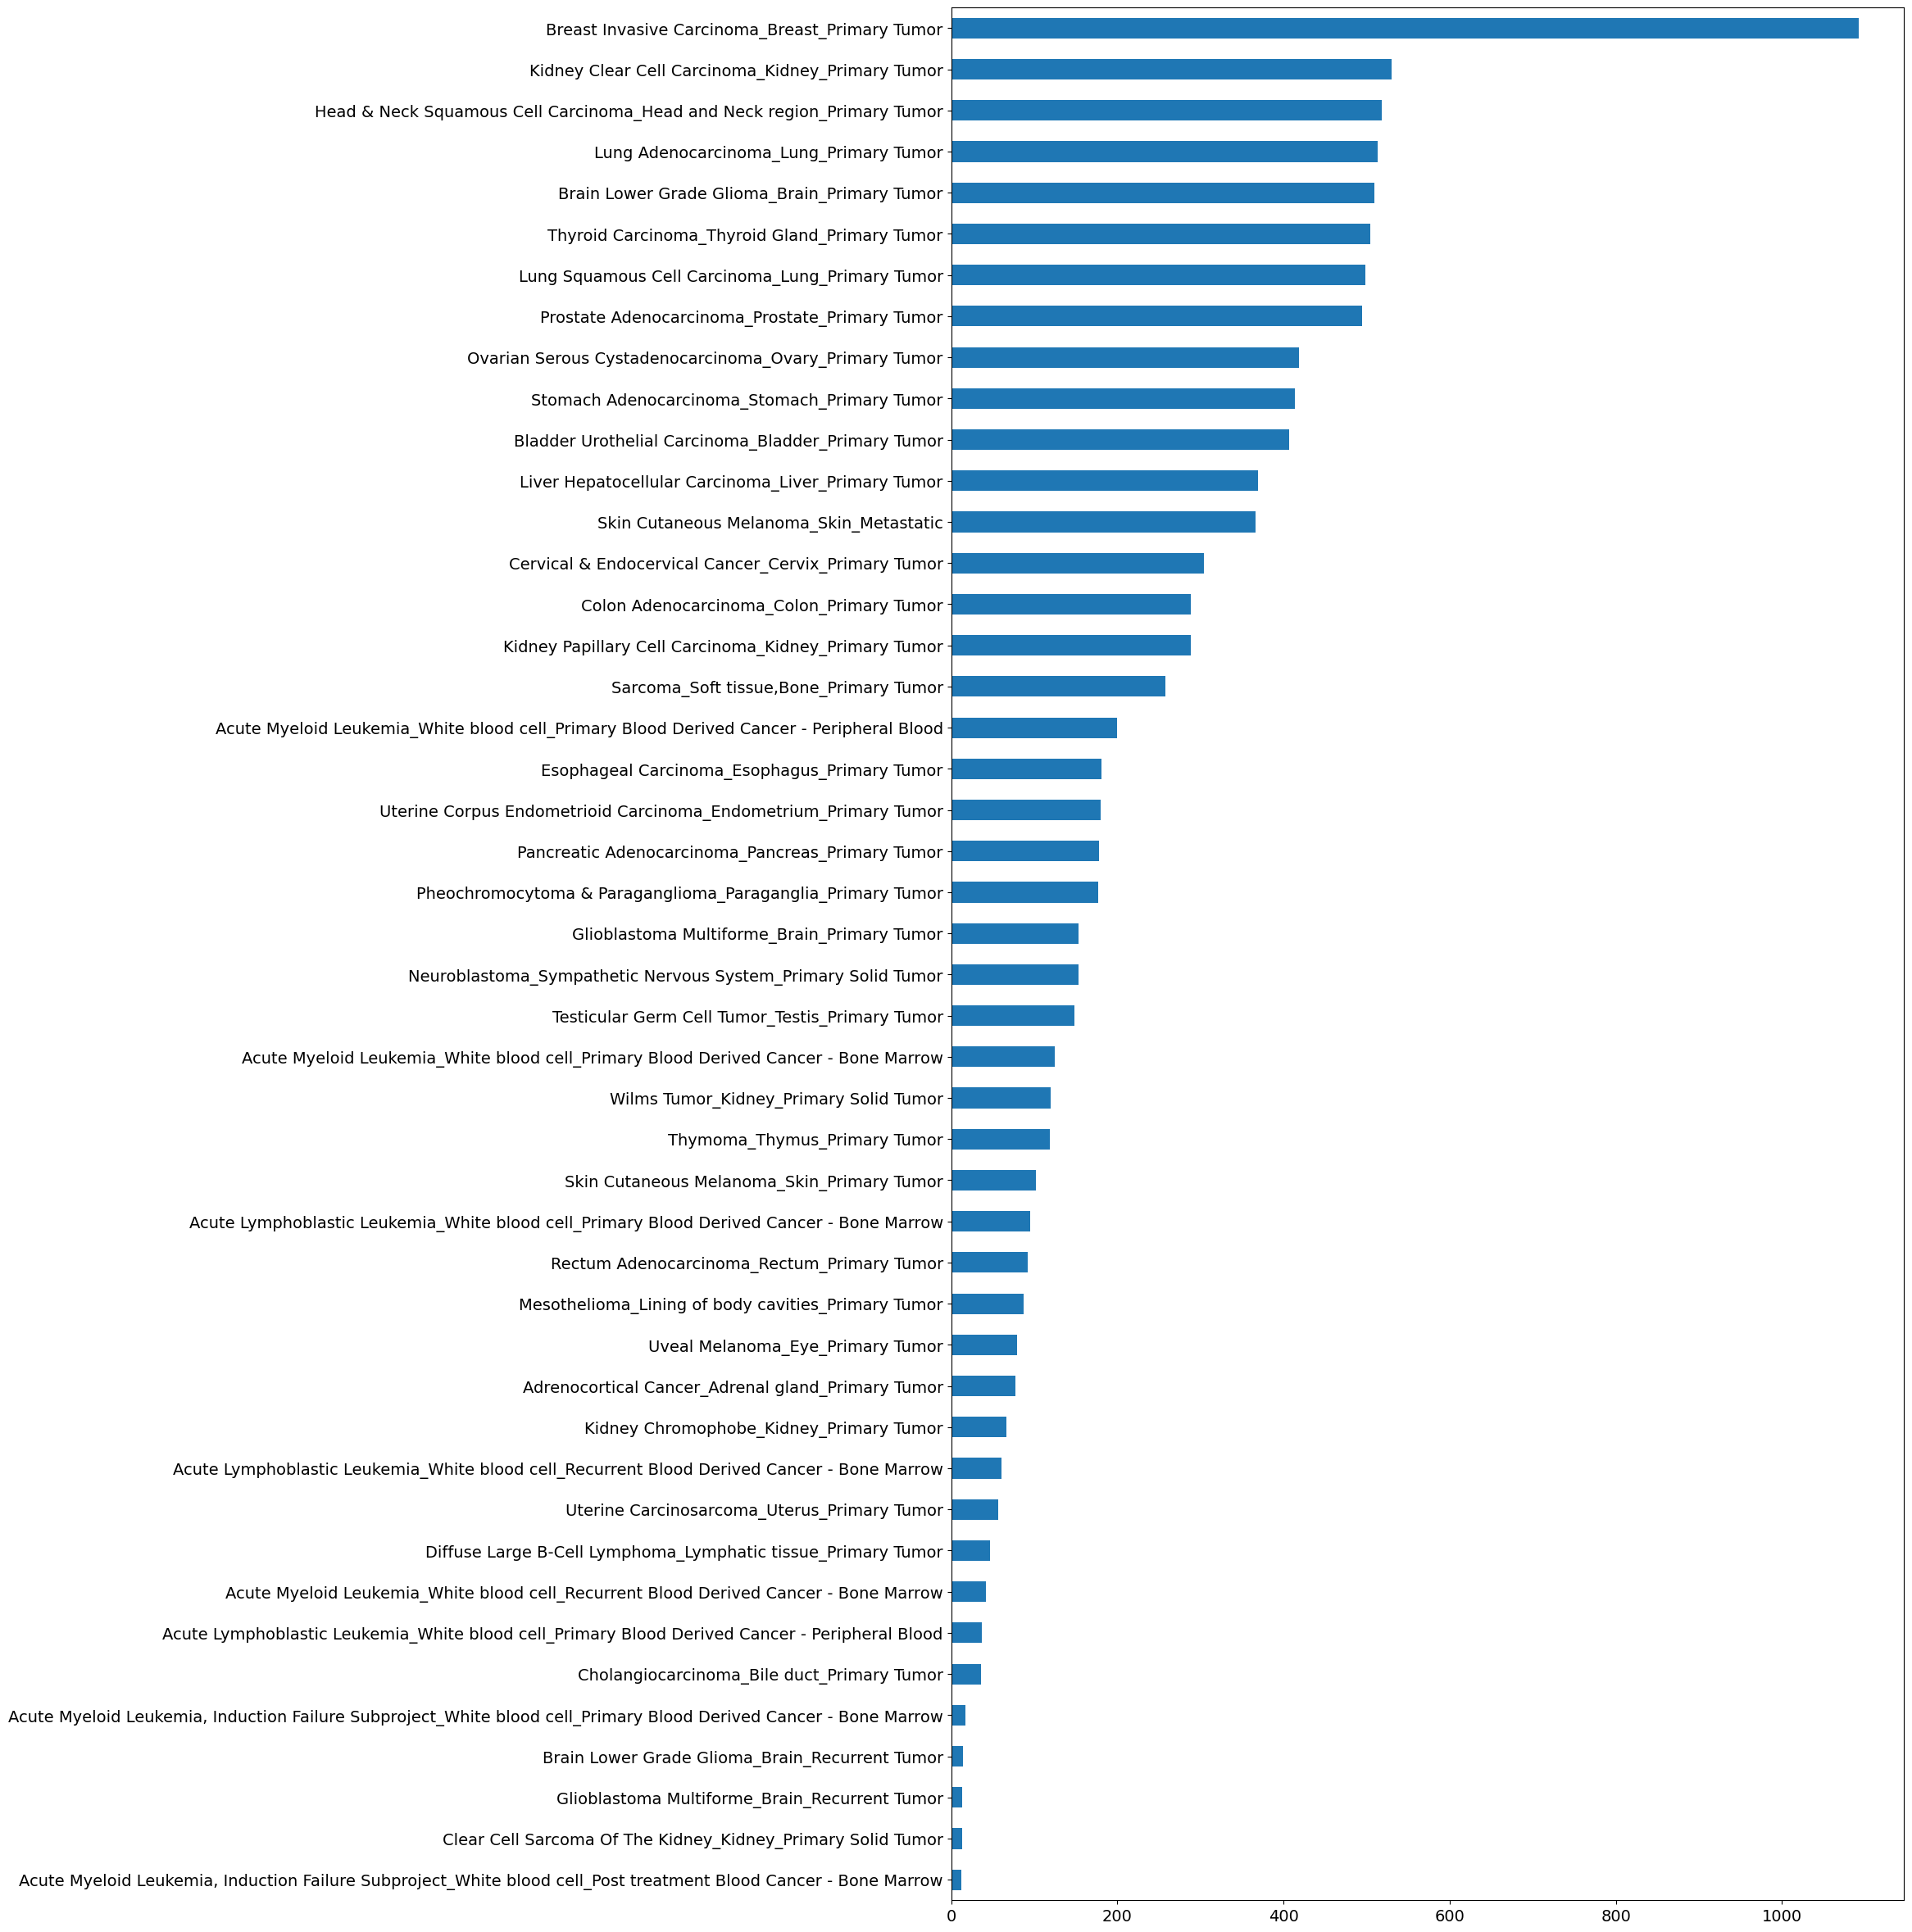

In [21]:
candf=pd.Series(can_dict_counts)
candf.sort_values(inplace=True)
plt.rcParams['figure.figsize'] = [15, 30]
matrixlist=list(candf.loc[candf>=10].index)
candf.loc[candf>=10].plot(kind='barh',fontsize=14)

In [23]:
genexpmatrix=pd.read_csv(UCSCtoilpath+"TcgaTargetGtex_rsem_gene_fpkm.gz",sep="\t",index_col=0)
genelist=genexpmatrix.index.to_series().apply(lambda x: x.split('.')[0]).values.tolist()
genexpmatrix.index=genelist

In [25]:
matrixlist

['Acute Myeloid Leukemia, Induction Failure Subproject_White blood cell_Post treatment Blood Cancer - Bone Marrow',
 'Clear Cell Sarcoma Of The Kidney_Kidney_Primary Solid Tumor',
 'Glioblastoma Multiforme_Brain_Recurrent Tumor',
 'Brain Lower Grade Glioma_Brain_Recurrent Tumor',
 'Acute Myeloid Leukemia, Induction Failure Subproject_White blood cell_Primary Blood Derived Cancer - Bone Marrow',
 'Cholangiocarcinoma_Bile duct_Primary Tumor',
 'Acute Lymphoblastic Leukemia_White blood cell_Primary Blood Derived Cancer - Peripheral Blood',
 'Acute Myeloid Leukemia_White blood cell_Recurrent Blood Derived Cancer - Bone Marrow',
 'Diffuse Large B-Cell Lymphoma_Lymphatic tissue_Primary Tumor',
 'Uterine Carcinosarcoma_Uterus_Primary Tumor',
 'Acute Lymphoblastic Leukemia_White blood cell_Recurrent Blood Derived Cancer - Bone Marrow',
 'Kidney Chromophobe_Kidney_Primary Tumor',
 'Adrenocortical Cancer_Adrenal gland_Primary Tumor',
 'Uveal Melanoma_Eye_Primary Tumor',
 'Mesothelioma_Lining of 

In [26]:
test=genexpmatrix.loc[:,genexpmatrix.columns.intersection(can_dict["Breast Invasive Carcinoma_Breast_Primary Tumor"])]

In [27]:
test=test.apply(lambda v: v-v.mean(),axis=1)

In [29]:
from tidepy.pred import TIDE
tideres=TIDE(test,"Other",ignore_norm=True)

[WARN] 39.24 % Genes are missing after converting to Entrez ID


In [34]:
tideoutputpath="/home/ajayasha/scratch/Arvind_umd/Results/TIDEpy/"
for mtype in matrixlist:
    test=genexpmatrix.loc[:,genexpmatrix.columns.intersection(can_dict[mtype])]
    test=test.apply(lambda v: v-v.mean(),axis=1)
    if "Melanoma" in mtype:
        ctype="Melanoma"
    elif "Lung" in mtype:
        ctype="NSCLC"
    else:
        ctype="Other"
    tideres=TIDE(test,ctype,ignore_norm=True)
    tideres.to_csv(tideoutputpath+mtype+"_tide.tsv",sep="\t")

[WARN] 39.24 % Genes are missing after converting to Entrez ID
[WARN] 39.24 % Genes are missing after converting to Entrez ID
[WARN] 39.24 % Genes are missing after converting to Entrez ID
[WARN] 39.24 % Genes are missing after converting to Entrez ID
[WARN] 39.24 % Genes are missing after converting to Entrez ID
[WARN] 39.24 % Genes are missing after converting to Entrez ID
[WARN] 39.24 % Genes are missing after converting to Entrez ID
[WARN] 39.24 % Genes are missing after converting to Entrez ID
[WARN] 39.24 % Genes are missing after converting to Entrez ID
[WARN] 39.24 % Genes are missing after converting to Entrez ID
[WARN] 39.24 % Genes are missing after converting to Entrez ID
[WARN] 39.24 % Genes are missing after converting to Entrez ID
[WARN] 39.24 % Genes are missing after converting to Entrez ID
[WARN] 39.24 % Genes are missing after converting to Entrez ID
[WARN] 39.24 % Genes are missing after converting to Entrez ID
[WARN] 39.24 % Genes are missing after converting to En